In [2]:
import pandas as pd
import numpy as np
import sqlalchemy as db
import joblib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from src.get_all_data import get_all_data
from xgboost import XGBClassifier
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, average_precision_score
import warnings
warnings.filterwarnings('ignore')

In [3]:
engine = db.create_engine('sqlite:///../data/raw/data.db')
df = get_all_data(engine)

Searching for events

[+] US Federal Funds Rate
Skipped — next release on 2026-04-29 (not yet passed)

[+] US FOMC Statement
Skipped — next release on 2026-04-29 (not yet passed)

[+] US FOMC Press Conference
Skipped — next release on 2026-04-29 (not yet passed)

[+] US FOMC Economic Projections
Skipped — next release on 2026-06-17 (not yet passed)

[+] US Core CPI m/m
Skipped — next release on 2026-04-10 (not yet passed)

[+] US CPI m/m
Skipped — next release on 2026-04-10 (not yet passed)

[+] US CPI y/y
Skipped — next release on 2026-04-10 (not yet passed)

[+] US PPI m/m
Skipped — next release on 2026-04-14 (not yet passed)

[+] US Core PCE Price Index m/m
Skipped — next release on 2026-04-09 (not yet passed)

[+] US Non-Farm Employment Change
Skipped — next release on 2026-04-03 (not yet passed)

[+] US Unemployment Rate
Skipped — next release on 2026-04-03 (not yet passed)

[+] US Average Hourly Earnings m/m
Skipped — next release on 2026-04-03 (not yet passed)

[+] US Advance GD

In [4]:
hmm = joblib.load('../models/hmm_model.pkl')
pca = joblib.load('../models/pca.pkl')
scaler = joblib.load('../models/scaler.pkl')

X_scaled = scaler.transform(df)
X_pca    = pca.transform(X_scaled)


n_states = hmm.n_components
state_probs = hmm.predict_proba(X_pca)
state_predict = hmm.predict(X_pca)


df['state'] = state_predict

for i in range(n_states):
    df[f'prob_state_{i}'] = state_probs[:, i]

In [5]:
df['spy_return'] = df['spy_close'].pct_change()
df['qqq_return'] = df['qqq_close'].pct_change()
df['^vix_return'] = df['^vix_close'].pct_change()
df['dx-y.nyb_return'] = df['dx-y.nyb_close'].pct_change()
df['gc=f_return'] = df['gc=f_close'].pct_change()

return_cols = {
    'spy_return':       'SPY',
    'qqq_return':       'QQQ',
    '^vix_return':      'VIX',
    'dx-y.nyb_return':  'DXY',
    'gc=f_return':      'Gold',
}

rows = []
for state in sorted(df['state'].unique()):
    mask = df['state'] == state
    row = {'state': state, 'count': mask.sum()}
    for col, name in return_cols.items():
        ret = df.loc[mask, col]
        row[f'{name}_mean']   = ret.mean()
        row[f'{name}_std']    = ret.std()
        row[f'{name}_sharpe'] = ret.mean() / ret.std()
    rows.append(row)

regime_profile = pd.DataFrame(rows).set_index('state')

#see all states
df_reset = regime_profile.reset_index()
df_long = df_reset.melt(id_vars='state', var_name='variable', value_name='value')

df_long[['asset', 'metric']] = df_long['variable'].str.split('_', n = 1 ,expand=True)

df_final = df_long.pivot_table(
    index=['state', 'asset'],
    columns='metric',
    values='value'
).reset_index()

df_final.columns.name = None
df_final = df_final[['state', 'asset', 'mean', 'std', 'sharpe']]

for state, group in df_final.groupby('state'):
    print(f"\nSTATE {state}")
    print(group.to_string(index= False))


STATE 0
 state asset     mean      std   sharpe
     0   DXY 0.000240 0.006217 0.038589
     0  Gold 0.000587 0.011980 0.048997
     0   QQQ 0.001832 0.014600 0.125449
     0   SPY 0.001353 0.011544 0.117174
     0   VIX 0.003683 0.117092 0.031454

STATE 1
 state asset      mean      std    sharpe
     1   DXY -0.000149 0.006029 -0.024757
     1  Gold  0.002594 0.012838  0.202050
     1   QQQ  0.002104 0.015668  0.134295
     1   SPY  0.001681 0.011714  0.143486
     1   VIX  0.003532 0.096328  0.036662

STATE 2
 state asset      mean      std    sharpe
     2   DXY -0.000222 0.009561 -0.023236
     2  Gold  0.002426 0.027556  0.088038
     2   QQQ -0.000099 0.032074 -0.003096
     2   SPY -0.001287 0.031497 -0.040847
     2   VIX  0.023685 0.171303  0.138262

STATE 3
 state asset     mean      std   sharpe
     3   DXY 0.000054 0.007003 0.007647
     3  Gold 0.000578 0.017356 0.033328
     3   QQQ 0.001479 0.016539 0.089416
     3   SPY 0.001057 0.014281 0.074048
     3   VIX 0.00396

In [6]:
macro_cols = {
    'US Federal Funds Rate':          'Fed Funds',
    'US Unemployment Rate':           'Unemployment',
    'US Non-Farm Employment Change':  'NFP',
    'US Housing Starts':              'Housing Starts',
    'US CPI m/m':                     'CPI m/m',
    'US Core CPI m/m':                'Core CPI',
    'US ISM Manufacturing PMI':       'ISM Mfg',
    'US Retail Sales m/m':            'Retail Sales',
    'BAMLH0A0HYM2':                   'HY Spread',
    'BAMLC0A0CM':                     'IG Spread',
}

rows = []
for state in sorted(df['state'].unique()):
    mask = df['state'] == state
    row = {'state': state, 'count': mask.sum()}
    for col, name in macro_cols.items():
        row[f'{name}'] = df.loc[mask, col].mean()
    rows.append(row)

macro_profile = pd.DataFrame(rows).set_index('state')

macro_profile

,count,Fed Funds,Unemployment,NFP,Housing Starts,CPI m/m,Core CPI,ISM Mfg,Retail Sales,HY Spread,IG Spread
state,,,,,,,,,,,
0,610,0.012246,0.044508,191019.672131,1.195328e+06,0.001367,0.001698,54.173115,0.002639,4.502787,1.319689
1,362,0.048881,0.038936,216781.767956,1.384420e+06,0.002442,0.002923,48.261326,0.002594,3.568591,1.068923
2,246,0.015132,0.067122,-653699.186992,1.038740e+06,-0.000764,0.001073,46.462195,-0.003037,8.684431,2.810244
3,788,0.009924,0.076278,74365.482234,8.304949e+05,0.002179,0.001505,53.498350,0.003416,5.761929,1.826586
4,267,0.006423,0.054049,510235.955056,1.586030e+06,0.005689,0.004333,58.138577,0.009251,3.960936,1.165843


In [7]:

asset_config = {
    'spy_return':      {'weight': 0.20, 'direction':  1},
    'qqq_return':      {'weight': 0.15, 'direction':  1},
    '^vix_return':     {'weight': 0.15, 'direction': -1}, #VIX hihg = bad
    'dx-y.nyb_return': {'weight': 0.05, 'direction':  1},
    'gc=f_return':     {'weight': 0.05, 'direction':  1},
}

macro_config = {
    # Monetary
    'US Federal Funds Rate':         {'weight': 0.05, 'direction': -1},  # high rates = bad
    # Employment
    'US Unemployment Rate':          {'weight': 0.05, 'direction': -1},  # high unemployment = bad
    'US Non-Farm Employment Change': {'weight': 0.05, 'direction':  1},  # more employment = good
    # Activity
    'US ISM Manufacturing PMI':      {'weight': 0.05, 'direction':  1},  # >50 = expansion
    'US Housing Starts':             {'weight': 0.03, 'direction':  1},  # more builds = good
    'US Retail Sales m/m':           {'weight': 0.03, 'direction':  1},  # strong expendings = good
    # Inflation
    'US CPI m/m':                    {'weight': 0.02, 'direction': -1},  # high inflation = bad
    'US Core CPI m/m':               {'weight': 0.02, 'direction': -1},
    # Credits
    'BAMLH0A0HYM2':                  {'weight': 0.05, 'direction': -1},  # HY spread high = bad
    'BAMLC0A0CM':                    {'weight': 0.05, 'direction': -1},  # IG spread high = bad
}

# wheights must sum 1
total_weight = (
    sum(c['weight'] for c in asset_config.values()) +
    sum(c['weight'] for c in macro_config.values())
)
print(f"Total weight: {total_weight:.2f}")


#macro stats
macro_global_stats = {}
for col in macro_config:
    macro_global_stats[col] = {
        'mean': df[col].mean(),
        'std':  df[col].std(),
    }


#composite score by state
rows = []
for state in sorted(df['state'].unique()):
    mask = df['state'] == state
    row  = {'state': state, 'n_days': mask.sum()}
    composite = 0.0

    # Market: Sharpe adjust by direction
    for col, cfg in asset_config.items():
        ret        = df.loc[mask, col].dropna()
        sharpe     = ret.mean() / ret.std() if ret.std() > 0 else 0
        sharpe_adj = sharpe * cfg['direction']
        row[f'asset_{col}'] = sharpe_adj
        composite += sharpe_adj * cfg['weight']

    # Macro: z-score adjust by direction
    for col, cfg in macro_config.items():
        state_mean = df.loc[mask, col].mean()
        g_mean     = macro_global_stats[col]['mean']
        g_std      = macro_global_stats[col]['std']
        zscore     = (state_mean - g_mean) / g_std if g_std > 0 else 0
        zscore_adj = zscore * cfg['direction']
        row[f'macro_{col}'] = zscore_adj
        composite += zscore_adj * cfg['weight']

    row['composite_score'] = composite
    rows.append(row)

signal_df = pd.DataFrame(rows).set_index('state')

max_abs = signal_df['composite_score'].abs().max()
signal_df['signal_size'] = signal_df['composite_score'] / max_abs


#results
print(signal_df[['n_days', 'composite_score', 'signal_size']].round(4))


signal_map = signal_df['signal_size'].to_dict()
df['primary_signal'] = df['state'].map(signal_map)

Total weight: 1.00
       n_days  composite_score  signal_size
state                                      
0         610           0.1452       0.5967
1         362           0.0415       0.1707
2         246          -0.2434      -1.0000
3         788          -0.0338      -0.1388
4         267           0.1587       0.6519


In [8]:
# ── PASO 1: estados candidatos del HMM ───────────────────────────────────────
prob_cols   = [f'prob_state_{s}' for s in range(n_states)]
prob_matrix = df[prob_cols].values
sorted_idx  = np.argsort(prob_matrix, axis=1)[:, ::-1]  # descendente

df['state_1st'] = sorted_idx[:, 0]
df['state_2nd'] = sorted_idx[:, 1]
df['prob_1st']  = prob_matrix[np.arange(len(df)), df['state_1st'].values]
df['prob_2nd']  = prob_matrix[np.arange(len(df)), df['state_2nd'].values]
df['prob_gap']  = df['prob_1st'] - df['prob_2nd']

# Señal de cada candidato (usando los signal_sizes que ya tienes)
df['signal_1st'] = df['state_1st'].map(signal_map)
df['signal_2nd'] = df['state_2nd'].map(signal_map)

# ── PASO 2: meta-label ────────────────────────────────────────────────────────
# Target: retorno de SPY al día siguiente (simple y sin circularidad)
df['spy_return_next'] = df['spy_return'].shift(-1)

# ¿Qué señal ganó más dinero ese día?
df['pnl_1st'] = df['signal_1st'] * df['spy_return_next']
df['pnl_2nd'] = df['signal_2nd'] * df['spy_return_next']

# 1 = quedarse con el estado del HMM
# 0 = mejor usar el segundo estado
df['meta_label'] = (df['pnl_1st'] >= df['pnl_2nd']).astype(int)

print("Balance meta-label:")
print(df['meta_label'].value_counts())
print(f"\n% días que el HMM acertó vs estado 2: {df['meta_label'].mean():.2%}")

Balance meta-label:
meta_label
1    1262
0    1011
Name: count, dtype: int64

% días que el HMM acertó vs estado 2: 55.52%


In [9]:
# Confianza del HMM
hmm_features = (
    [f'prob_state_{s}' for s in range(n_states)] +
    ['prob_gap', 'prob_1st', 'prob_2nd']
)

# Técnicos SPY
tech_features = [
    'spy_RSI_14', 'spy_RSI_21',
    'spy_MACD_hist',
    'spy_AROON_up', 'spy_AROON_down',
    'spy_MFI',
]

# VIX
vix_features = ['^vix_close', '^vix_RSI_14']

# Macro
macro_features = [
    'BAMLH0A0HYM2', 'BAMLC0A0CM',
    'US ISM Manufacturing PMI',
    'US Federal Funds Rate',
    'US Unemployment Rate',
]

# Retornos rezagados
for lag in [1, 2, 3, 5]:
    df[f'spy_lag{lag}'] = df['spy_return'].shift(lag)
lag_features = [f'spy_lag{lag}' for lag in [1, 2, 3, 5]]

# Volatilidad
df['vol_5d']    = df['spy_return'].rolling(5).std()
df['vol_20d']   = df['spy_return'].rolling(20).std()
df['vol_ratio'] = df['vol_5d'] / (df['vol_20d'] + 1e-10)
vol_features    = ['vol_5d', 'vol_20d', 'vol_ratio']

feature_cols = (
    hmm_features +
    ['signal_diff', 'signal_1st', 'signal_2nd'] +
    tech_features + vix_features + macro_features +
    lag_features + vol_features
)
feature_cols = [c for c in feature_cols if c in df.columns]
print(f"Total features: {len(feature_cols)}")

Total features: 30


In [10]:
cols_needed = feature_cols + [
    'meta_label', 'spy_return_next',
    'signal_1st', 'signal_2nd', 'state_1st'
]

df_clean = df[cols_needed].dropna().copy()
df_clean = df_clean[~df_clean.index.duplicated(keep='last')]
df_clean = df_clean.loc[:, ~df_clean.columns.duplicated(keep='last')]

X = df_clean[feature_cols].values
y = df_clean['meta_label'].values

print(f"Filas: {len(df_clean)}")
print(f"Período: {df_clean.index[0].date()} → {df_clean.index[-1].date()}")
print(f"Balance: {y.mean():.2%} positivos (estado 1 fue mejor)")

Filas: 2252
Período: 2007-05-31 → 2026-03-18
Balance: 55.37% positivos (estado 1 fue mejor)


In [11]:
N_SPLITS  = 5
TEST_SIZE = int(len(X) * 0.15)
tscv      = TimeSeriesSplit(n_splits=N_SPLITS, test_size=TEST_SIZE)

xgb_params = {'n_estimators': 106, 'max_depth': 3, 'learning_rate': 0.007142617026703015, 'subsample': 0.7248407280330155, 'colsample_bytree': 0.953161975612878, 'gamma': 0.00024099875083526207, 'min_child_weight': 2, 'scale_pos_weight': 2.3084348180507566}

all_probs = np.full(len(y), np.nan)

for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
    X_tr, X_te = X[train_idx], X[test_idx]
    y_tr, y_te = y[train_idx], y[test_idx]

    sc      = StandardScaler()
    X_tr_s  = sc.fit_transform(X_tr)
    X_te_s  = sc.transform(X_te)

    model = XGBClassifier(**xgb_params)
    model.fit(X_tr_s, y_tr, eval_set=[(X_te_s, y_te)], verbose=False)

    proba = model.predict_proba(X_te_s)[:, 1]
    all_probs[test_idx] = proba

    auc = roc_auc_score(y_te, proba)
    ap  = average_precision_score(y_te, proba)
    print(f"Fold {fold+1}: ROC-AUC={auc:.3f} | Avg-Prec={ap:.3f}")

# ── Modelo final ──────────────────────────────────────────────────────────────
sc_final   = StandardScaler()
X_final    = sc_final.fit_transform(X)
meta_model = XGBClassifier(**xgb_params)
meta_model.fit(X_final, y, verbose=False)

# meta_prob: P(estado 1 es mejor que estado 2)
df_clean['meta_prob'] = meta_model.predict_proba(X_final)[:, 1]

Fold 1: ROC-AUC=0.505 | Avg-Prec=0.550
Fold 2: ROC-AUC=0.530 | Avg-Prec=0.583
Fold 3: ROC-AUC=0.567 | Avg-Prec=0.602
Fold 4: ROC-AUC=0.562 | Avg-Prec=0.618
Fold 5: ROC-AUC=0.497 | Avg-Prec=0.548


In [12]:
import optuna
import numpy as np
from xgboost import XGBClassifier
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score

def objective(trial):
    # Definición del espacio de búsqueda de hiperparámetros
    param = {
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'n_estimators': 2000,
        'min_child_weight': trial.suggest_int('min_child_weight', 5, 50),
        'subsample': trial.suggest_float('subsample', 0.6, 0.9),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 0.9),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 0.8, 2.0)
    }

    # Usamos el mismo TimeSeriesSplit que definiste en tu Celda 9
    tscv = TimeSeriesSplit(n_splits=5)
    aucs = []

    # Validación cruzada
    # X e y ya deben estar definidos en tu notebook (Celda 8)
    for train_index, val_index in tscv.split(X):
        X_tr, X_val = X[train_index], X[val_index]
        y_tr, y_val = y[train_index], y[val_index]

        # Aplicamos el escalado dentro de la validación para evitar fugas de datos
        sc = StandardScaler()
        X_tr_s = sc.fit_transform(X_tr)
        X_val_s = sc.transform(X_val)

        model = XGBClassifier(**param)
        model.fit(X_tr_s, y_tr)

        preds = model.predict_proba(X_val_s)[:, 1]
        auc = roc_auc_score(y_val, preds)
        aucs.append(auc)

    return np.mean(aucs)

# Crear el estudio y optimizar
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=300) # Puedes subir n_trials a 100 para mejores resultados

print("Mejores parámetros encontrados:")
print(study.best_params)
print(f"Mejor ROC AUC: {study.best_value:.4f}")

[I 2026-03-21 16:40:24,663] A new study created in memory with name: no-name-f27b821f-578b-4329-9516-e26805ff2928
[I 2026-03-21 16:40:27,000] Trial 0 finished with value: 0.4969441302175598 and parameters: {'max_depth': 3, 'learning_rate': 0.03566014618470875, 'min_child_weight': 19, 'subsample': 0.8779208483248064, 'colsample_bytree': 0.8674569356603403, 'reg_alpha': 0.00856553377813733, 'reg_lambda': 0.33886352741673204, 'scale_pos_weight': 1.059184570555831}. Best is trial 0 with value: 0.4969441302175598.
[I 2026-03-21 16:40:29,198] Trial 1 finished with value: 0.4886582932727725 and parameters: {'max_depth': 5, 'learning_rate': 0.03146753982569288, 'min_child_weight': 37, 'subsample': 0.6929779540644843, 'colsample_bytree': 0.7383418291344466, 'reg_alpha': 0.3480174002005755, 'reg_lambda': 0.5701381079782445, 'scale_pos_weight': 0.9980609276842585}. Best is trial 0 with value: 0.4969441302175598.
[I 2026-03-21 16:40:31,412] Trial 2 finished with value: 0.49922882880012126 and para

Mejores parámetros encontrados:
{'max_depth': 3, 'learning_rate': 0.010026398924870316, 'min_child_weight': 5, 'subsample': 0.8522588736883068, 'colsample_bytree': 0.652290496210238, 'reg_alpha': 0.001019739378947891, 'reg_lambda': 0.002810185867537254, 'scale_pos_weight': 1.8641664447440551}
Mejor ROC AUC: 0.5217


In [13]:
# Señal = mezcla ponderada entre estado 1 y estado 2
# meta_prob=0.9 → 90% estado 1 + 10% estado 2  (HMM confiable)
# meta_prob=0.5 → 50/50                          (HMM dudoso → transición suave)
# meta_prob=0.1 → 10% estado 1 + 90% estado 2   (override del HMM)
df_clean['final_signal'] = (
    df_clean['meta_prob'].values       * df_clean['signal_1st'].values +
    (1 - df_clean['meta_prob'].values) * df_clean['signal_2nd'].values
)

print(df_clean[['signal_1st', 'signal_2nd', 'meta_prob', 'final_signal']]
      .tail(10).round(3))

            signal_1st  signal_2nd  meta_prob  final_signal
date                                                       
2026-02-20        -1.0       0.171      0.730        -0.683
2026-02-27        -1.0       0.171      0.724        -0.677
2026-03-02        -1.0       0.171      0.729        -0.683
2026-03-04        -1.0       0.171      0.736        -0.691
2026-03-06        -1.0       0.171      0.723        -0.676
2026-03-10        -1.0       0.171      0.726        -0.679
2026-03-11        -1.0       0.171      0.725        -0.678
2026-03-12        -1.0       0.171      0.733        -0.688
2026-03-13        -1.0       0.171      0.725        -0.678
2026-03-18        -1.0       0.171      0.732        -0.686


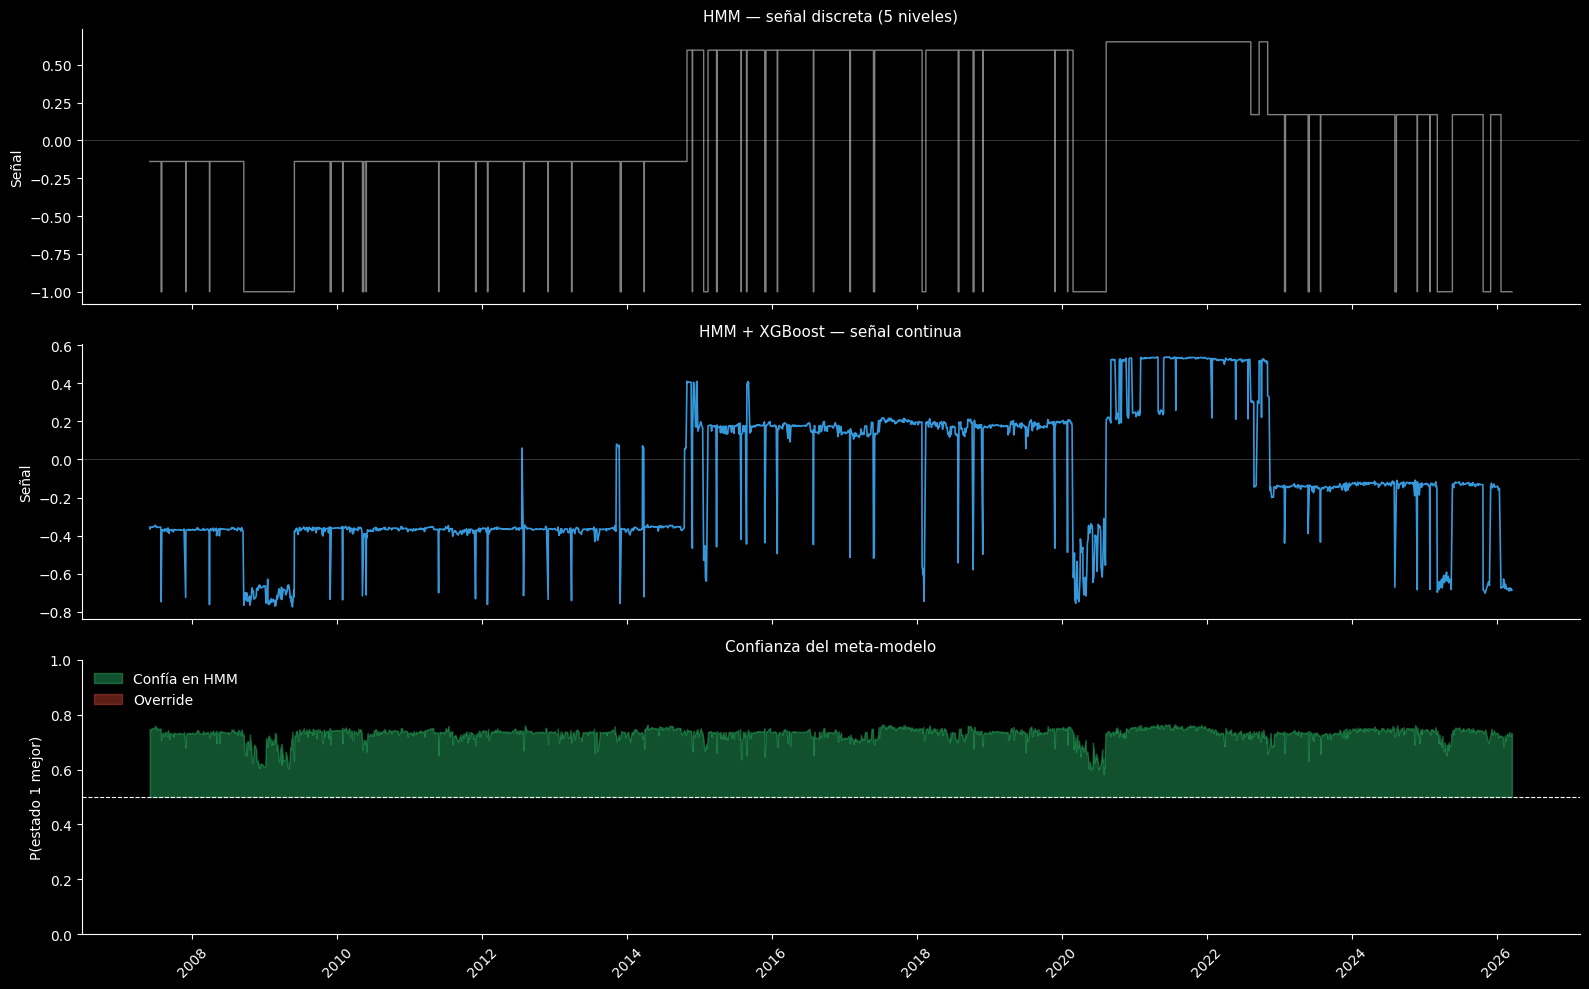

In [14]:
plt.style.use('dark_background')
fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)

# Panel 1: señal discreta del HMM
axes[0].plot(df_clean.index, df_clean['signal_1st'].values,
             color='gray', lw=1, drawstyle='steps-post')
axes[0].axhline(0, color='white', lw=0.5, alpha=0.3)
axes[0].set_ylabel('Señal')
axes[0].set_title('HMM — señal discreta (5 niveles)', fontsize=11)

# Panel 2: señal continua post meta-modelo
axes[1].plot(df_clean.index, df_clean['final_signal'].values,
             color='#3498db', lw=1.2)
axes[1].axhline(0, color='white', lw=0.5, alpha=0.3)
axes[1].set_ylabel('Señal')
axes[1].set_title('HMM + XGBoost — señal continua', fontsize=11)

# Panel 3: confianza del meta-modelo
meta_vals = df_clean['meta_prob'].values
axes[2].fill_between(df_clean.index, meta_vals, 0.5,
                     where=meta_vals >= 0.5,
                     color='#2ecc71', alpha=0.4, label='Confía en HMM')
axes[2].fill_between(df_clean.index, meta_vals, 0.5,
                     where=meta_vals < 0.5,
                     color='#e74c3c', alpha=0.4, label='Override')
axes[2].axhline(0.5, color='white', lw=0.8, linestyle='--')
axes[2].set_ylim(0, 1)
axes[2].set_ylabel('P(estado 1 mejor)')
axes[2].set_title('Confianza del meta-modelo', fontsize=11)
axes[2].legend(frameon=False, loc='upper left')
axes[2].xaxis.set_major_locator(mdates.YearLocator(2))
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=45)

for ax in axes:
    for sp in ['top', 'right']:
        ax.spines[sp].set_visible(False)

plt.tight_layout()
plt.savefig('hmm_vs_meta.png', dpi=150, bbox_inches='tight')
plt.show()

In [15]:
# ── PROBLEMA: meta_prob oscila → cambios diarios de estado ───────
# SOLUCIÓN: suavizar meta_prob con ventana rodante antes de decidir

# Opción 1: rolling mean (suave)
df_clean['meta_prob_smooth'] = (
    pd.Series(df_clean['meta_prob'].values, index=df_clean.index)
    .rolling(window=10, min_periods=1, center=False)
    .mean()
)

# Opción 2: añadir histéresis (más robusto)
# Solo cambiar de estado si la señal es clara durante varios días
# Zona muerta: entre 0.40 y 0.60 → mantener estado actual
def apply_hysteresis(meta_prob_series, state_1st, state_2nd,
                     upper=0.60, lower=0.40):
    """
    Solo hacer override si meta_prob < lower de forma sostenida.
    En la zona muerta [lower, upper] → mantener el estado anterior.
    """
    states = np.zeros(len(meta_prob_series), dtype=int)
    current = state_1st[0]   # empezar con el estado del HMM

    for i, (p, s1, s2) in enumerate(zip(meta_prob_series, state_1st, state_2nd)):
        if p >= upper:
            current = s1   # confianza alta → estado HMM
        elif p <= lower:
            current = s2   # confianza baja → estado 2
        # else: zona muerta → mantener estado anterior (current no cambia)
        states[i] = current

    return states

# ── Aplicar las dos opciones y comparar ──────────────────────────
# Rolling smooth + threshold 0.5
df_clean['state_smooth'] = np.where(
    df_clean['meta_prob_smooth'].values >= 0.5,
    df_clean['state_1st'].values,
    df.loc[df_clean.index, 'state_2nd'].values
)

# Histéresis
df_clean['state_hysteresis'] = apply_hysteresis(
    df_clean['meta_prob'].values,
    df_clean['state_1st'].values,
    df.loc[df_clean.index, 'state_2nd'].values,
    upper=0.60, lower=0.40
)

# ── Contar cambios de estado (métrica de ruido) ───────────────────
def count_transitions(states):
    return (np.diff(states) != 0).sum()

print(f"Cambios HMM original:   {count_transitions(df_clean['state_1st'].values)}")
print(f"Cambios meta (raw):     {count_transitions(df_clean['state_corrected'].values)}")
print(f"Cambios meta (smooth):  {count_transitions(df_clean['state_smooth'].values)}")
print(f"Cambios meta (hister.): {count_transitions(df_clean['state_hysteresis'].values)}")

Cambios HMM original:   87


KeyError: 'state_corrected'

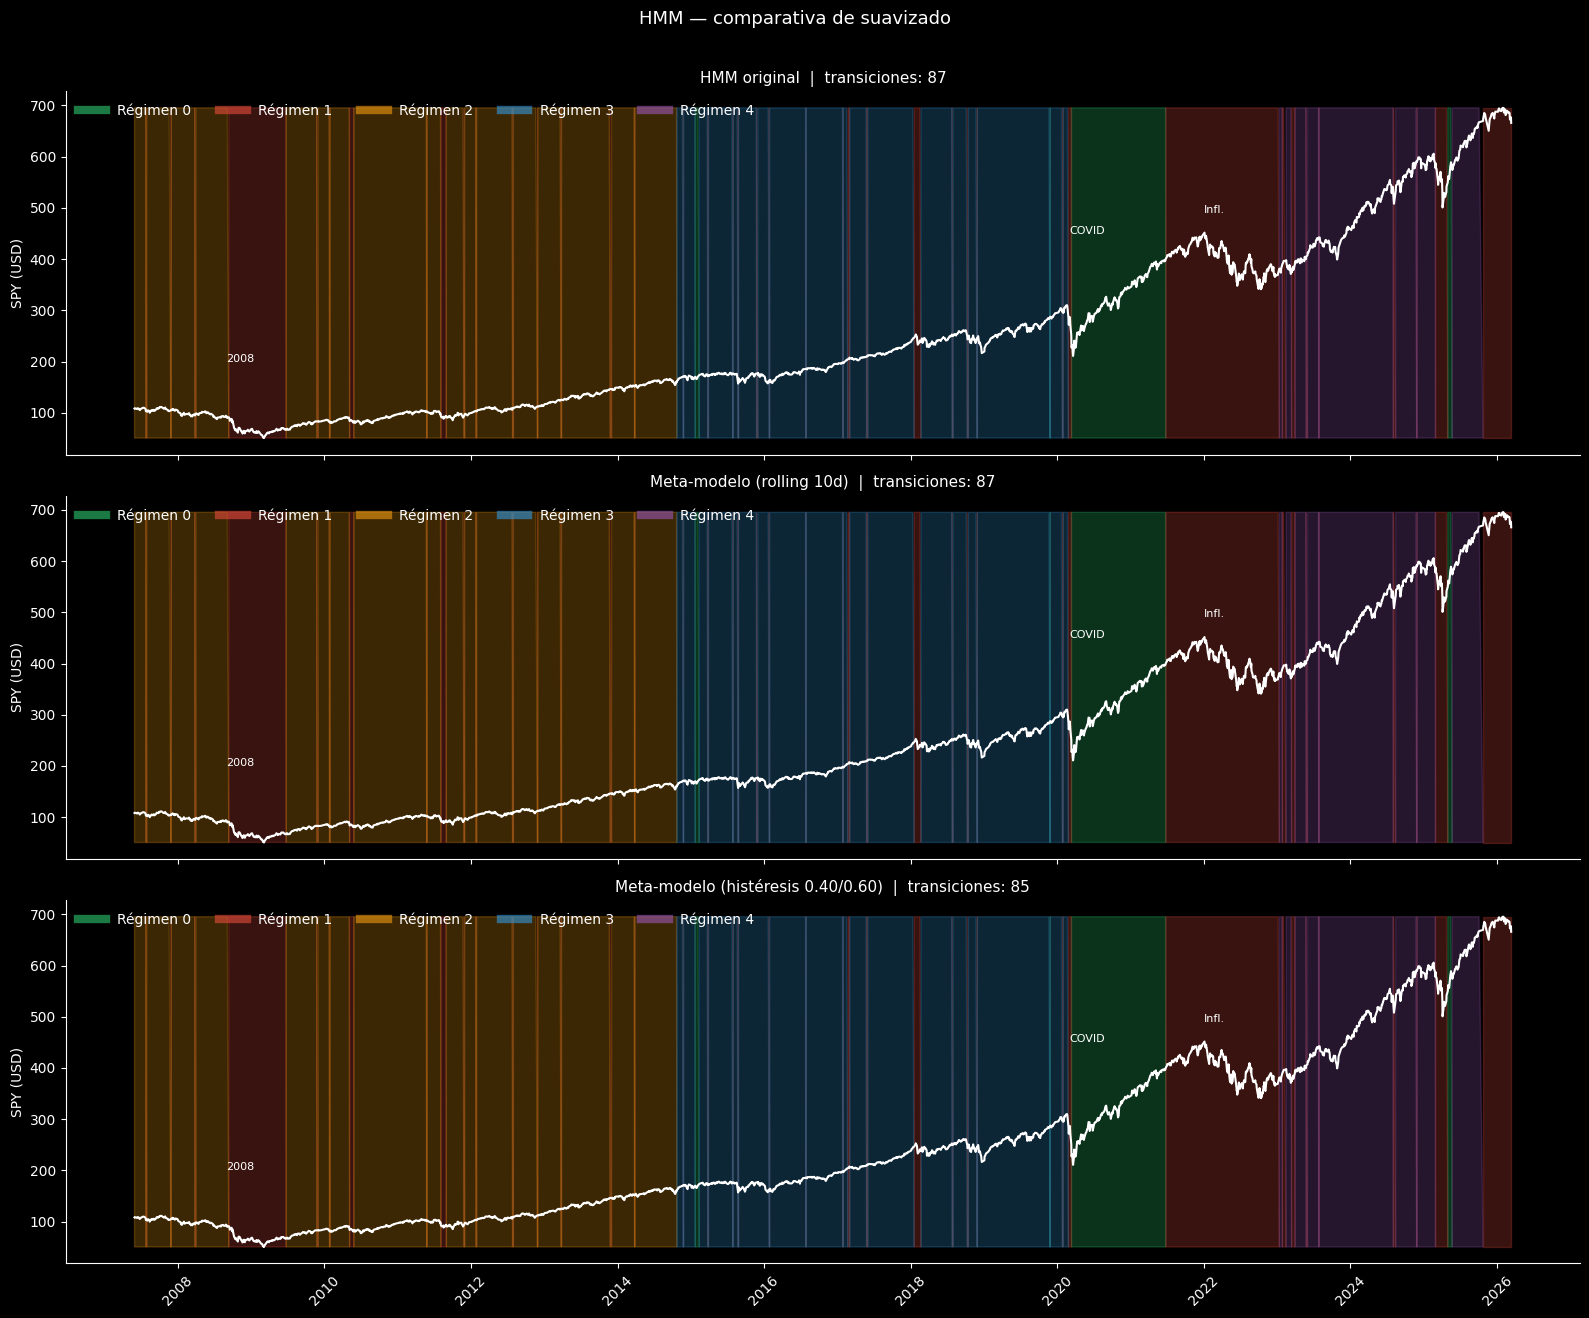

In [24]:
# ── Gráfico comparativo de las 3 versiones ────────────────────────
spy_close = df.loc[df_clean.index, 'spy_close']
colors    = ['#2ecc71', '#e74c3c', '#f39c12', '#3498db', '#9b59b6']
spy_min, spy_max = spy_close.min(), spy_close.max()

fig, axes = plt.subplots(3, 1, figsize=(16, 13), sharex=True)

for ax, state_col, title in zip(
    axes,
    ['state_1st', 'state_smooth', 'state_hysteresis'],
    ['HMM original',
     'Meta-modelo (rolling 10d)',
     'Meta-modelo (histéresis 0.40/0.60)']
):
    ax.plot(df_clean.index, spy_close, color='white', lw=1.5, zorder=3)

    for regime_id, color in enumerate(colors):
        mask = df_clean[state_col] == regime_id
        ax.fill_between(
            df_clean.index,
            spy_min, spy_max,
            where=mask.values,
            color=color, alpha=0.25,
            interpolate=True
        )

    n_trans = count_transitions(df_clean[state_col].values)
    ax.set_ylabel('SPY (USD)')
    ax.set_title(f'{title}  |  transiciones: {n_trans}', fontsize=11)

    handles = [plt.Line2D([0], [0], color=c, lw=6, alpha=0.6) for c in colors]
    labels  = [f'Régimen {i}' for i in range(n_states)]
    ax.legend(handles, labels, loc='upper left', frameon=False, ncol=5)

    ax.text(pd.Timestamp('2008-09-01'), 200,  '2008',  color='white', fontsize=8)
    ax.text(pd.Timestamp('2020-03-01'), 450,  'COVID', color='white', fontsize=8)
    ax.text(pd.Timestamp('2022-01-01'), 490,  'Infl.', color='white', fontsize=8)

    for sp in ['top', 'right']:
        ax.spines[sp].set_visible(False)

axes[2].xaxis.set_major_locator(mdates.YearLocator(2))
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=45)

plt.suptitle('HMM — comparativa de suavizado', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('regimes_smoothed.png', dpi=200, bbox_inches='tight')
plt.show()


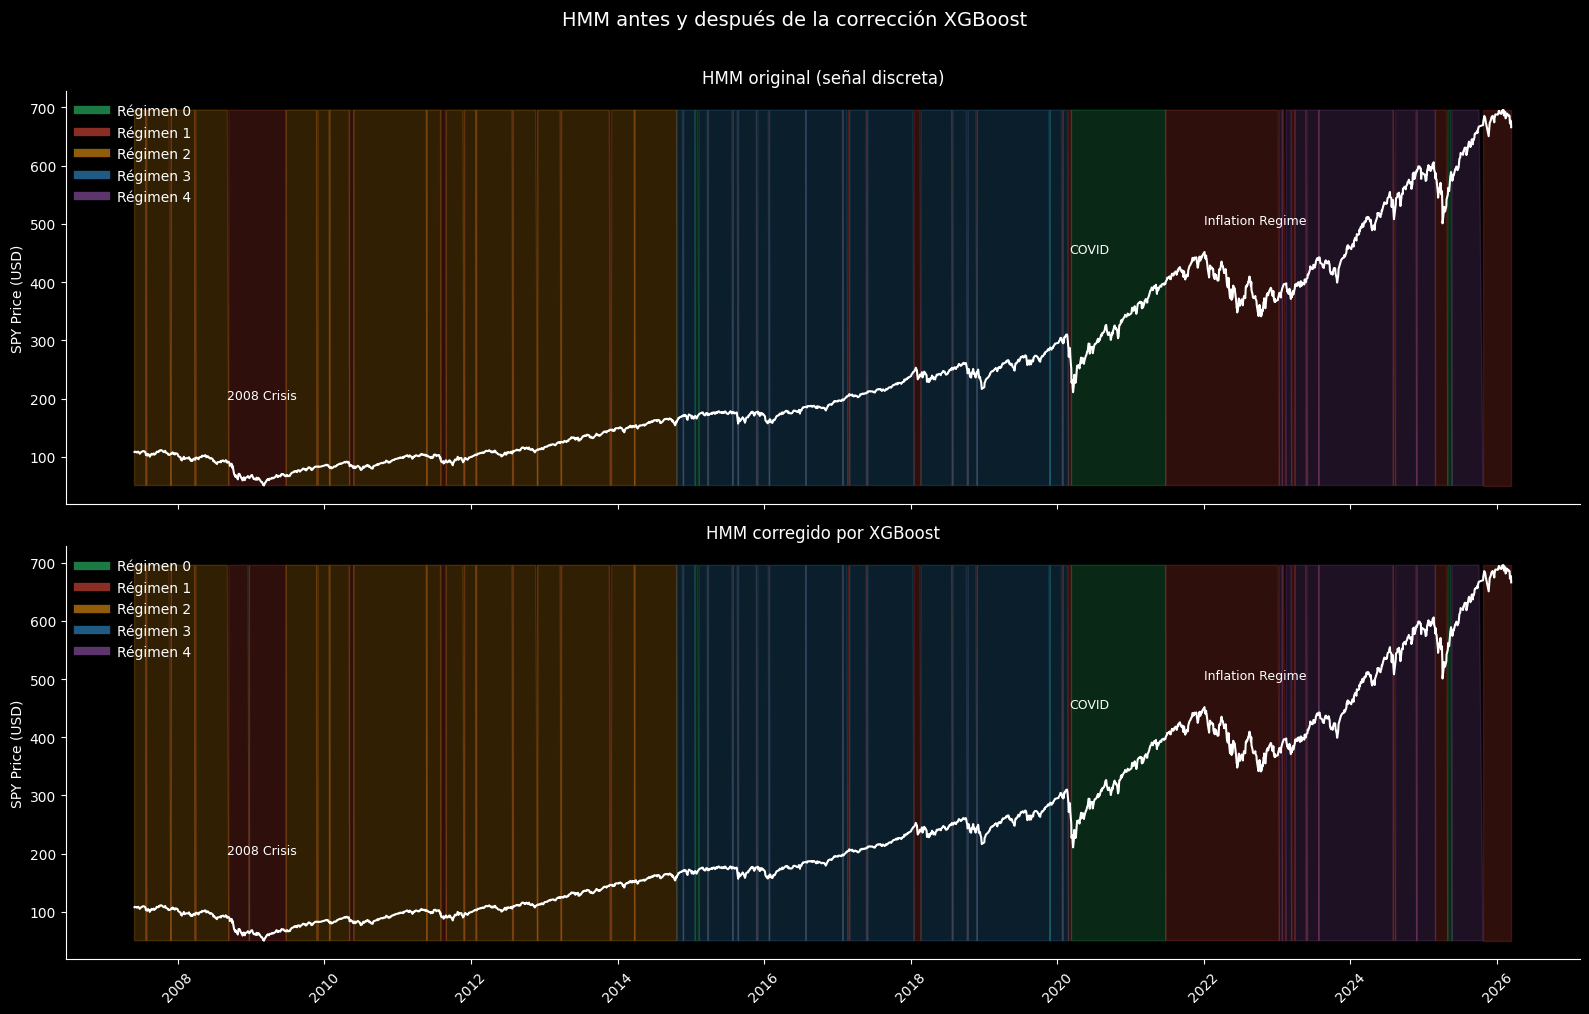

Días corregidos: 1 de 2250 (0.0%)

Cambios más frecuentes:
state_1st  state_corrected
1          0                  1
Name: n_dias, dtype: int64


In [32]:
plt.style.use("dark_background")

# ── Estado corregido: si meta_prob < 0.5 → usar estado 2 ─────────
df_clean['state_corrected'] = np.where(
    df_clean['meta_prob'].values >= 0.6,
    df_clean['state_1st'].values,
    df.loc[df_clean.index, 'state_2nd'].values
)

# ── Comparativa ───────────────────────────────────────────────────
spy_close = df.loc[df_clean.index, 'spy_close']
colors    = ['#2ecc71', '#e74c3c', '#f39c12', '#3498db', '#9b59b6']

fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

spy_min = spy_close.min()
spy_max = spy_close.max()

for ax, state_col, title in zip(
    axes,
    ['state_1st', 'state_corrected'],
    ['HMM original (señal discreta)', 'HMM corregido por XGBoost']
):
    ax.plot(df_clean.index, spy_close, color='white', lw=1.5, zorder=3)

    for regime_id, color in enumerate(colors):
        mask = df_clean[state_col] == regime_id
        ax.fill_between(
            df_clean.index,
            spy_min, spy_max,
            where=mask.values,
            color=color, alpha=0.20,
            interpolate=True
        )

    ax.set_ylabel('SPY Price (USD)')
    ax.set_title(title, fontsize=12)

    handles = [plt.Line2D([0], [0], color=c, lw=6, alpha=0.6) for c in colors]
    labels  = [f'Régimen {i}' for i in range(n_states)]
    ax.legend(handles, labels, loc='upper left', frameon=False)

    ax.text(pd.Timestamp('2008-09-01'), 200,  '2008 Crisis',       color='white', fontsize=9)
    ax.text(pd.Timestamp('2020-03-01'), 450,  'COVID',             color='white', fontsize=9)
    ax.text(pd.Timestamp('2022-01-01'), 500,  'Inflation Regime',  color='white', fontsize=9)

    for sp in ['top', 'right']:
        ax.spines[sp].set_visible(False)

axes[1].xaxis.set_major_locator(mdates.YearLocator(2))
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=45)

plt.suptitle('HMM antes y después de la corrección XGBoost', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('regimes_corrected.png', dpi=300, bbox_inches='tight')
plt.show()

# ── Cuántos días se corrigieron ───────────────────────────────────
n_corrected = (df_clean['state_1st'] != df_clean['state_corrected']).sum()
print(f"Días corregidos: {n_corrected} de {len(df_clean)} ({n_corrected/len(df_clean):.1%})")

# ── Cambios más frecuentes ────────────────────────────────────────
corrections = df_clean[df_clean['state_1st'] != df_clean['state_corrected']]
cambios = corrections.groupby(['state_1st', 'state_corrected']).size()
cambios.name = 'n_dias'
print("\nCambios más frecuentes:")
print(cambios.sort_values(ascending=False).head(10))